### Initiate library

In [1]:
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os
from PIL import Image

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("--- using device:", DEVICE)

--- using device: cuda


### Get the data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/DataSet/FINAL_DATASET.csv")
# print(df.head(3))
print("label distribution:")
print(df['label'].value_counts())

print("\split distribution:")
print(df['dataset_split'].value_counts())

Mounted at /content/drive
label distribution:
label
FAKE    3767
REAL    2790
Name: count, dtype: int64
\split distribution:
dataset_split
train    4593
test     1323
val       641
Name: count, dtype: int64


In [3]:
print("--- dataset shape:", df.shape)

df.info()

df.isnull().sum()

--- dataset shape: (6557, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6557 entries, 0 to 6556
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image_id              6557 non-null   int64  
 1   image_url             6557 non-null   object 
 2   label                 6557 non-null   object 
 3   label_numeric         6557 non-null   int64  
 4   category              6557 non-null   object 
 5   gender                6557 non-null   object 
 6   age_group             6557 non-null   object 
 7   source                6557 non-null   object 
 8   fake_method           3767 non-null   object 
 9   image_quality         6557 non-null   object 
 10  resolution            6557 non-null   object 
 11  confidence_score      6557 non-null   float64
 12  detection_difficulty  6557 non-null   object 
 13  dataset_split         6557 non-null   object 
 14  date_collected        6557 non-null   obje

,0
image_id,0
image_url,0
label,0
label_numeric,0
category,0
gender,0
age_group,0
source,0
fake_method,2790
image_quality,0


### Download image first

In [4]:
SAVE_DIR = "/content/images"
os.makedirs(f"{SAVE_DIR}/REAL", exist_ok=True)
os.makedirs(f"{SAVE_DIR}/FAKE", exist_ok=True)

failed = []

for idx, row in df.iterrows():
    label    = row['label']        # REAL atau FAKE
    image_id = row['image_id']
    url      = row['image_url']
    save_path = f"{SAVE_DIR}/{label}/{image_id}.jpg"

    # Skip kalau udah pernah di-download
    if os.path.exists(save_path):
        continue

    try:
        response = requests.get(url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        img.save(save_path)
    except Exception as e:
        failed.append(image_id)

    if idx % 100 == 0:
        print(f"Progress: {idx}/{len(df)}")

print(f"\nSelesai! Gagal download: {len(failed)} gambar")

Progress: 0/6557
Progress: 100/6557
Progress: 200/6557
Progress: 300/6557
Progress: 400/6557
Progress: 500/6557
Progress: 600/6557
Progress: 700/6557
Progress: 800/6557
Progress: 900/6557
Progress: 1000/6557
Progress: 1100/6557
Progress: 1200/6557
Progress: 1300/6557
Progress: 1400/6557
Progress: 1500/6557
Progress: 1600/6557
Progress: 1700/6557
Progress: 1800/6557
Progress: 1900/6557
Progress: 2000/6557
Progress: 2100/6557
Progress: 2200/6557
Progress: 2300/6557
Progress: 2400/6557
Progress: 2500/6557
Progress: 2600/6557
Progress: 2700/6557
Progress: 2800/6557
Progress: 2900/6557
Progress: 3000/6557
Progress: 3100/6557
Progress: 3200/6557
Progress: 3300/6557
Progress: 3400/6557
Progress: 3500/6557
Progress: 3600/6557
Progress: 3700/6557
Progress: 3800/6557
Progress: 3900/6557
Progress: 4000/6557
Progress: 4100/6557
Progress: 4200/6557
Progress: 4300/6557
Progress: 4400/6557
Progress: 4500/6557
Progress: 4600/6557
Progress: 4700/6557
Progress: 4800/6557
Progress: 4900/6557
Progress: 50

In [38]:
def file_exists(row):
    return os.path.exists(f"{SAVE_DIR}/{row['label']}/{row['image_id']}.jpg")

df = df[df.apply(file_exists, axis=1)].reset_index(drop=True)
print(f"Dataset setelah filter: {len(df)} baris")

Dataset setelah filter: 5557 baris


### Setup custom dataset

In [39]:
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS     = 10
LR         = 0.0001
DROPOUT    = 0.4

### Setup dataset

In [45]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# val for validation
val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# class FaceDataset(torch.utils.data.Dataset):
#     def __init__(self, df, img_dir, transform=None):
#         self.df = df
#         self.img_dir = img_dir
#         self.transform = transform

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         row = self.df.iloc[idx]
#         label = 1 if row['label'] == 'REAL' else 0
#         image_id = row['image_id']
#         image_path = f"{SAVE_DIR}/{row['label']}/{image_id}.jpg"

#         try:
#             image = Image.open(image_path).convert("RGB")
#             if self.transform:
#                 image = self.transform(image)
                
#             return image, label
#         except Exception as e:
#             print(f"--- Error loading image {image_path}: {e}")
#             return None
    # def __getitem__(self, idx):
    #     try:
    #         image = Image.open(self.image_paths[idx]).convert("RGB")
    #         label = self.labels[idx]
    #         if self.transform:
    #             image = self.transform(image)
    #         return image, label
    #     except Exception as e:
    #         print(f"[WARNING] Skipping corrupt image at index {idx}: {e}")
    #         return None  # akan di-filter oleh collate_fn

class FaceDataset(torch.utils.data.Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label = 1 if row['label'] == 'REAL' else 0
        image_id = row['image_id']
        image_path = f"{SAVE_DIR}/{row['label']}/{image_id}.jpg"

        try:
            image = Image.open(image_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            else:
                image = transforms.ToTensor()(image)  # selalu jadi tensor
            return image, label
        except Exception as e:
            print(f"--- Error loading image {image_path}: {e}")
            return None  # akan di-filter collate_fn


# Tambahkan collate_fn ini
def collate_fn(batch):
    batch = [b for b in batch if b is not None]  # buang None
    if len(batch) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(batch)

### split data

In [46]:
train_df = df[df['dataset_split'] == 'train'].reset_index(drop=True)
test_df  = df[df['dataset_split'] == 'test'].reset_index(drop=True)

val_size = int(0.15 * len(train_df))
val_df = train_df.sample(n=val_size, random_state=42)
train_df = train_df.drop(val_df.index).reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"--- Train : {len(train_df)}")
print(f"--- Val   : {len(val_df)}")
print(f"--- Test  : {len(test_df)}")

train_set = FaceDataset(train_df, SAVE_DIR, transform=train_transform)
val_set   = FaceDataset(val_df, SAVE_DIR, transform=val_test_transform)
test_set  = FaceDataset(test_df, SAVE_DIR, transform=val_test_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"--- train_loader : {len(train_loader)}")
print(f"--- val_loader   : {len(val_loader)}")
print(f"--- test_loader  : {len(test_loader)}")

--- Train : 3302
--- Val   : 582
--- Test  : 1126
--- train_loader : 104
--- val_loader   : 19
--- test_loader  : 36


### Setup for model

In [50]:
class FaceCNN(nn.Module):
    def __init__(self, dropout=0.4):
        super(FaceCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
model = FaceCNN(dropout=DROPOUT).to(DEVICE)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
print(model)

FaceCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (3): Dropout2d(p=0.4, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (7): Dropout2d(p=0.4, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (11): Dropout2d(p=0.4, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


## Training

In [51]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predicted = (outputs >= 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE).float().unsqueeze(1).to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            predicted = (outputs >= 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"--- Epoch {epoch+1}/{EPOCHS} - "
          f"--- Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
          f"--- Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

--- Epoch 1/10 - --- Train Loss: 0.3516, Train Acc: 0.8504 - --- Val Loss: 0.2249, Val Acc: 0.9038
--- Epoch 2/10 - --- Train Loss: 0.2315, Train Acc: 0.9237 - --- Val Loss: 0.2202, Val Acc: 0.9158
--- Epoch 3/10 - --- Train Loss: 0.2181, Train Acc: 0.9285 - --- Val Loss: 0.1917, Val Acc: 0.9313
--- Epoch 4/10 - --- Train Loss: 0.2000, Train Acc: 0.9346 - --- Val Loss: 0.1747, Val Acc: 0.9347
--- Epoch 5/10 - --- Train Loss: 0.2000, Train Acc: 0.9319 - --- Val Loss: 0.1649, Val Acc: 0.9381
--- Epoch 6/10 - --- Train Loss: 0.1983, Train Acc: 0.9394 - --- Val Loss: 0.1890, Val Acc: 0.9296
--- Epoch 7/10 - --- Train Loss: 0.1996, Train Acc: 0.9334 - --- Val Loss: 0.1604, Val Acc: 0.9416
--- Epoch 8/10 - --- Train Loss: 0.1921, Train Acc: 0.9379 - --- Val Loss: 0.1681, Val Acc: 0.9381
--- Epoch 9/10 - --- Train Loss: 0.1910, Train Acc: 0.9412 - --- Val Loss: 0.1921, Val Acc: 0.9433
--- Epoch 10/10 - --- Train Loss: 0.1914, Train Acc: 0.9425 - --- Val Loss: 0.1681, Val Acc: 0.9433


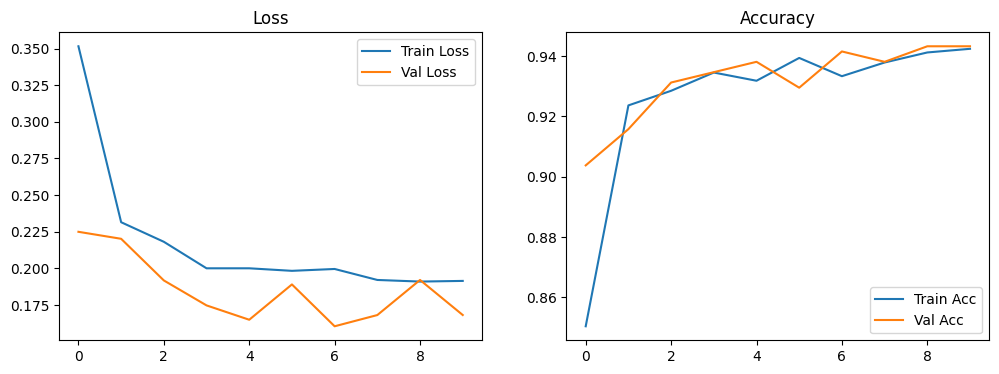

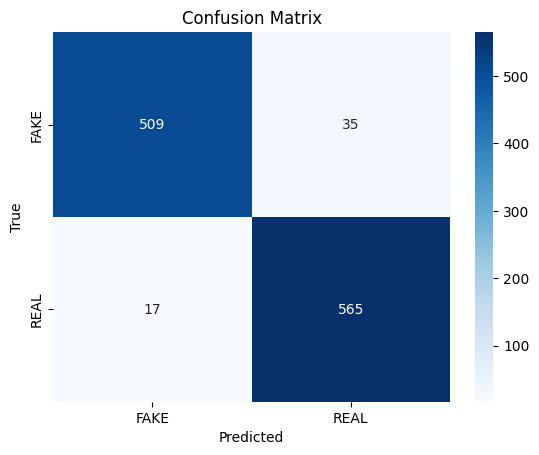

--- Test Accuracy: 95.38%


In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
# axes[0].set_title("Loss per Epoch")
axes[0].set_title("Loss")
# axes[0].set_xlabel("Epoch")
# axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.show()

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        preds   = (outputs >= 0.5).float().squeeze().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['FAKE','REAL'],
            yticklabels=['FAKE','REAL'])
plt.title("Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.show()

_, test_acc = evaluate(model, test_loader, criterion)
print(f"--- Test Accuracy: {test_acc*100:.2f}%")
